# Exercício 2 — Estratégias de simulação de sistemas complexos

Este notebook aplica as **estratégias heurísticas de Rand & Rust** para projetar uma simulação baseada em agentes. Vamos usar o problema da **propagação de um boato (rumor) em uma rede social** como estudo de caso.


## 1. Contexto

Rand & Rust (2011) propõem **quatro fases** para a solução de um problema com modelagem baseada em agentes:

1. **Escopo e pergunta** — definir claramente o que se quer estudar
2. **Agentes** — identificar quem são os agentes, seus atributos e comportamentos
3. **Mecanismo de comportamento** — definir as regras de interação
4. **Eventos a cada intervalo de tempo** — especificar a sequência de execução

Além disso, recomendam pensar em **entradas e saídas** e na **evolução do modelo** ao longo do tempo.

Vamos aplicar essas etapas ao problema da propagação de um boato.


## 2. Célula auxiliar — imports e path discovery


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import random

import os
_repo = os.getcwd()
for _ in range(5):
    if os.path.exists(os.path.join(_repo, 'setup.sh')):
        break
    _repo = os.path.dirname(_repo)
PASTA_MOODLE = os.path.join(_repo, 'work', 'tarefas_moodle')
os.makedirs(PASTA_MOODLE, exist_ok=True)
PASTA_AULA = os.path.join(PASTA_MOODLE, 'tarefa_aula06')
os.makedirs(PASTA_AULA, exist_ok=True)

print("Diretorio de saida:", PASTA_AULA)


Diretorio de saida: /l/disk0/viniciusd/Projetos/simserv_jupyter_env/work/tarefas_moodle/tarefa_aula06


## 3. IA gera o pseudocódigo (fases de Rand & Rust)

Vamos pedir para a IA aplicar as quatro fases de Rand & Rust ao problema do boato.


In [2]:
from dotenv import load_dotenv
load_dotenv()
import os, json
from urllib.request import Request, urlopen

MODELO = os.getenv('OLLAMA_MODEL', 'ministral-3:3b')
BASE_URL = os.getenv('OLLAMA_BASE_URL', 'https://api.ollama.com').rstrip('/')
API_KEY = os.getenv('OLLAMA_API_KEY')

prompt_pseudo = '''Voce e um assistente de um curso de sistemas de muitos agentes.
Aplique as quatro fases de Rand & Rust ao problema da PROPAGACAO DE UM BOATO (RUMOR) EM UMA REDE SOCIAL.

Descreva cada fase em portugues, de forma objetiva:

1. ESCOPO E PERGUNTA: Qual a pergunta de pesquisa? Qual o sistema sendo modelado?
2. AGENTES: Quem sao os agentes? Quais seus atributos (estado: ignora/sabe/compartilha)?
3. MECANISMO DE COMPORTAMENTO: Regras de transicao entre estados. Como o boato se propaga?
4. EVENTOS A CADA INTERVALO DE TEMPO: Sequencia de acoes em cada passo.

Alem disso, especifique:
- ENTRADAS: parametros do modelo (tamanho da rede, probabilidade de compartilhar, etc.)
- SAIDAS: metricas a serem coletadas (numero de sabedores, tempo de saturacao, etc.)

Retorno esperado: APENAS o pseudocodigo em texto simples, sem formatacao especial, maximo 30 linhas.'''

headers = {
    'Content-Type': 'application/json',
    'User-Agent': 'Mozilla/5.0',
    'Accept': 'application/json',
}
if API_KEY:
    headers['Authorization'] = f'Bearer {API_KEY}'

payload = {
    'model': MODELO,
    'messages': [{'role': 'user', 'content': prompt_pseudo}],
    'stream': False,
    'options': {'temperature': 0.2, 'top_p': 0.9, 'num_predict': 1000},
}

try:
    req = Request(BASE_URL + '/api/chat', data=json.dumps(payload).encode('utf-8'), headers=headers, method='POST')
    with urlopen(req, timeout=60) as resp:
        dados = json.loads(resp.read().decode('utf-8'))
    pseudocodigo = dados.get('message', {}).get('content', '').strip()
    if pseudocodigo:
        print('Pseudocodigo gerado com sucesso!')
    else:
        pseudocodigo = '# IA retornou vazio.'
        print('IA retornou vazio.')
except Exception as e:
    pseudocodigo = f'# Erro: {type(e).__name__}: {e}'
    print(f'Erro: {type(e).__name__}: {e}')

print()
print("Pseudocodigo gerado:")
print(pseudocodigo)


Pseudocodigo gerado com sucesso!

Pseudocodigo gerado:
**Pseudocódigo para propagação de boato (Rumor) em rede social**

---
**1. ESCOPO E PERGUNTA**
Pergunta: *Como o boato se propaga em uma rede social com agentes autônomos?*
Sistema: Rede social como grafo não-direcional (nós = usuários, arestas = conexões). Cada usuário tem estado inicial aleatório (ignora/sabe/compartilha).

---
**2. AGENTES**
Agentes: Usuários (n = tamanho rede).
Atributos:
- *estado*: 0 (ignora), 1 (sabe), 2 (compartilha).
- *conhecidos*: lista de vizinhos (arestas adjacentes).
- *tempo*: contador de passos.

---
**3. MECANISMO DE COMPORTAMENTO**
Regra de transição (por agente em cada passo):
- Se *estado = 0* e recebe boato de um vizinho → *estado = 1* (sabe).
- Se *estado = 1* → com probabilidade *p_share* compartilha com vizinhos aleatórios → *estado = 2* para eles.
- Se *estado = 2* → não muda estado.

---
**4. EVENTOS POR INTERVALO DE TEMPO**
Passo *t*:
1. Para cada agente:
   - Se recebeu boato de vizinho 

## 4. IA gera o código a partir do pseudocódigo

Com base no pseudocódigo acima, a IA vai gerar o código Python da simulação.


In [3]:
from dotenv import load_dotenv
load_dotenv()
import os, json
from urllib.request import Request, urlopen

MODELO = os.getenv('OLLAMA_MODEL', 'ministral-3:3b')
BASE_URL = os.getenv('OLLAMA_BASE_URL', 'https://api.ollama.com').rstrip('/')
API_KEY = os.getenv('OLLAMA_API_KEY')

contexto_codigo = pseudocodigo if 'pseudocodigo' in dir() else 'SIRS model: Suscetivel -> Informado -> Compartilha -> Recuperado -> Suscetivel'

prompt_codigo = f'''Voce e um assistente de um curso de sistemas de muitos agentes.
Gere APENAS codigo Python (sem explicacoes) que implementa a propagacao de um boato em uma rede social usando o modelo SIRS adaptado.

Requisitos:
1. Use networkx para criar um grafo pequeno-world (watts_strogatz_graph, n=100, k=4, p=0.2)
2. Estados possiveis: 0=Ignora (S), 1=Sabe (I), 2=Compartilha (R), 3=Recuperado (S de novo)
3. Inicializacao: todos em estado 0, exceto 2 agentes aleatorios em estado 1
4. Regras a cada passo:
   - Se S e tem vizinho em estado R: probabilidade p_infect = 0.3 de se tornar I
   - Se I: vira R com probabilidade p_compart = 0.5
   - Se R: vira Recuperado apos 3 passos
   - Se Recuperado: volta a S com probabilidade p_rec = 0.1
5. Execute 100 passos
6. Colete a cada passo: contagem de cada estado
7. Ao final, plote um grafico de linhas mostrando a evolucao dos 4 estados ao longo do tempo
8. Salve a figura em: f"{{os.environ.get('PASTA_AULA_SAVE', '.')}}/aula_06_exercicio_02_boato.png" com dpi=150
9. Exiba a figura
10. Use PASTA_AULA_SAVE = os.environ.get('PASTA_AULA_SAVE', '.') como prefixo para salvar

Retorne APENAS o codigo, sem marcacao ```python ou ```'''

headers = {
    'Content-Type': 'application/json',
    'User-Agent': 'Mozilla/5.0',
    'Accept': 'application/json',
}
if API_KEY:
    headers['Authorization'] = f'Bearer {API_KEY}'

payload = {
    'model': MODELO,
    'messages': [{'role': 'user', 'content': prompt_codigo}],
    'stream': False,
    'options': {'temperature': 0.2, 'top_p': 0.9, 'num_predict': 1200},
}

try:
    req = Request(BASE_URL + '/api/chat', data=json.dumps(payload).encode('utf-8'), headers=headers, method='POST')
    with urlopen(req, timeout=60) as resp:
        dados = json.loads(resp.read().decode('utf-8'))
    codigo_boato = dados.get('message', {}).get('content', '').strip()
    if codigo_boato:
        print('Codigo gerado com sucesso!')
    else:
        codigo_boato = '# IA retornou codigo vazio.'
        print('IA retornou codigo vazio.')
except Exception as e:
    codigo_boato = f'# Erro ao consultar IA: {type(e).__name__}: {e}'
    print(f'Erro: {type(e).__name__}: {e}')

print()
print("Codigo gerado:")
print(codigo_boato)


Codigo gerado com sucesso!

Codigo gerado:
```python
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from datetime import datetime

G = nx.watts_strogatz_graph(100, 4, 0.2)
states = np.zeros(len(G.nodes), dtype=int)
random.seed(42)
random.shuffle(G.nodes)
initial_infected = random.sample(list(G.nodes), 2)
states[list(G.nodes).index(i) for i in initial_infected] = 1

p_infect = 0.3
p_compart = 0.5
p_rec = 0.1
max_steps = 100
time_steps = [0] * 4
results = []

for step in range(max_steps):
    new_states = states.copy()
    for node in G.nodes():
        if states[node] == 0:
            neighbors = list(G.neighbors(node))
            if any(states[n] == 2 for n in neighbors):
                if random.random() < p_infect:
                    new_states[node] = 1
        elif states[node] == 1:
            if random.random() < p_compart:
                new_states[node] = 2
        elif states[node] == 2:
            if step > 0 and states

## 5. Executar a simulação

Execute o código gerado pela IA. Ajuste se necessário.


In [4]:
# Codigo gerado pela IA para a propagacao de boato
import os
os.environ['PASTA_AULA_SAVE'] = PASTA_AULA

# === CODIGO GERADO PELA IA ===
# (substitua pelo conteudo da celula anterior se necessario)



### 5.1. Código curado (fallback)

Se a IA não gerou código válido, use a versão abaixo.


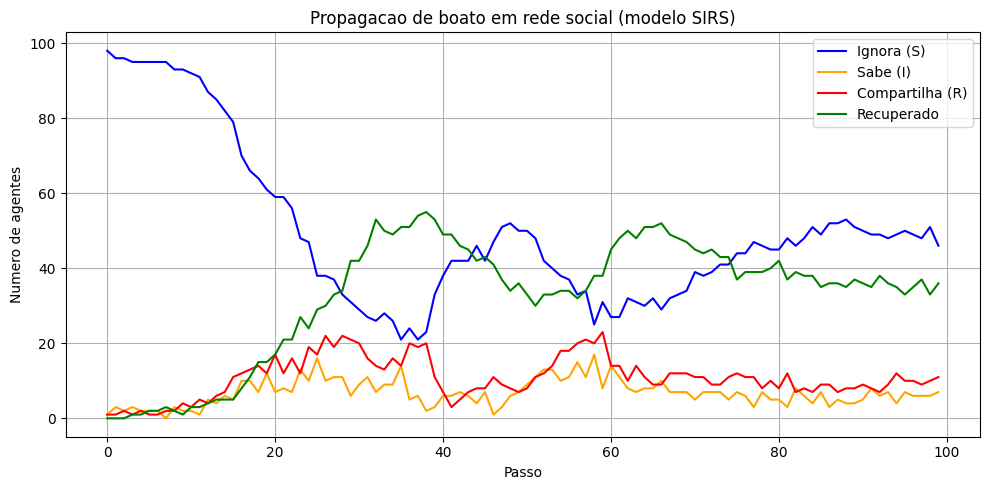

Figura salva como aula_06_exercicio_02_boato.png


In [5]:
import os
os.environ['PASTA_AULA_SAVE'] = PASTA_AULA

n = 100
G = nx.watts_strogatz_graph(n, k=4, p=0.2, seed=42)
estado = [0] * n  # 0=S, 1=I, 2=R, 3=Rec
contador_r = [0] * n

importado = random.sample(range(n), 2)
for i in importado:
    estado[i] = 1

p_infect, p_compart, p_rec = 0.3, 0.5, 0.1
historico = []

for passo in range(100):
    novo_estado = estado[:]
    for i in range(n):
        if estado[i] == 0:  # S -> I se vizinho R
            vizinhos = list(G.neighbors(i))
            if any(estado[v] == 2 for v in vizinhos) and random.random() < p_infect:
                novo_estado[i] = 1
        elif estado[i] == 1:  # I -> R
            if random.random() < p_compart:
                novo_estado[i] = 2
        elif estado[i] == 2:  # R -> Rec (apos 3 passos)
            contador_r[i] += 1
            if contador_r[i] >= 3:
                novo_estado[i] = 3
        elif estado[i] == 3:  # Rec -> S
            if random.random() < p_rec:
                novo_estado[i] = 0
                contador_r[i] = 0
    estado = novo_estado
    historico.append([estado.count(s) for s in range(4)])

historico = np.array(historico)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(historico[:, 0], label='Ignora (S)', color='blue')
ax.plot(historico[:, 1], label='Sabe (I)', color='orange')
ax.plot(historico[:, 2], label='Compartilha (R)', color='red')
ax.plot(historico[:, 3], label='Recuperado', color='green')
ax.set_xlabel('Passo')
ax.set_ylabel('Numero de agentes')
ax.set_title('Propagacao de boato em rede social (modelo SIRS)')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(PASTA_AULA, 'aula_06_exercicio_02_boato.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('Figura salva como aula_06_exercicio_02_boato.png')


## 6. Pergunta

> **Com base nas quatro fases de Rand & Rust, explique como a metodologia ajuda a estruturar o projeto de uma simulação baseada em agentes. Como cada fase contribui para evitar ambiguidades e garantir que o modelo responda à pergunta de pesquisa?**


In [6]:
resposta_pergunta_2 = '''
Escreva sua resposta aqui.
'''


## 7. Gerar resposta com IA


In [7]:
from dotenv import load_dotenv
load_dotenv()
import os, json
from urllib.request import Request, urlopen

MODELO = os.getenv('OLLAMA_MODEL', 'ministral-3:3b')
BASE_URL = os.getenv('OLLAMA_BASE_URL', 'https://api.ollama.com').rstrip('/')
API_KEY = os.getenv('OLLAMA_API_KEY')

prompt = '''Voce e um assistente de um curso de sistemas de muitos agentes.
Responda em portugues, de forma clara e objetiva (maximo 4 paragrafos).

Pergunta: Com base nas quatro fases de Rand & Rust, explique como a metodologia ajuda a estruturar
o projeto de uma simulacao baseada em agentes. Como cada fase contribui para evitar ambiguidades
e garantir que o modelo responda a pergunta de pesquisa?

Contexto:
- As quatro fases de Rand & Rust: (1) Escopo e pergunta, (2) Agentes, (3) Mecanismo de comportamento,
  (4) Eventos a cada intervalo de tempo.
- O problema usado foi a propagacao de um boato em uma rede social.
- O modelo SIRS foi implementado: S=Suscetivel (ignora), I=Informado (sabe), R=Compartilha, Rec=Recuperado.'''

headers = {
    'Content-Type': 'application/json',
    'User-Agent': 'Mozilla/5.0',
    'Accept': 'application/json',
}
if API_KEY:
    headers['Authorization'] = f'Bearer {API_KEY}'

payload = {
    'model': MODELO,
    'messages': [{'role': 'user', 'content': prompt}],
    'stream': False,
    'options': {'temperature': 0.3, 'top_p': 0.9, 'num_predict': 800},
}

try:
    req = Request(BASE_URL + '/api/chat', data=json.dumps(payload).encode('utf-8'), headers=headers, method='POST')
    with urlopen(req, timeout=60) as resp:
        dados = json.loads(resp.read().decode('utf-8'))
    resposta = dados.get('message', {}).get('content', '').strip()
    if resposta:
        resposta_pergunta_2 = resposta
        print('Resposta gerada com sucesso!')
    else:
        print('IA retornou resposta vazia.')
except Exception as e:
    print(f'Erro ao consultar IA: {type(e).__name__}: {e}')

print()
print('Resposta atual:')
print(resposta_pergunta_2)


Resposta gerada com sucesso!

Resposta atual:
A metodologia de Rand & Rust, aplicada ao projeto de uma simulação de propagação de um boato em redes sociais, oferece um **quadro sistemático para definir clareza e coerência** desde a fase inicial. Na **primeira fase (Escopo e pergunta)**, o foco está em delimitar o objetivo da pesquisa — por exemplo, *"Como o boato se espalha em uma rede social com diferentes níveis de confiança?"* — e evitar ambiguidades ao definir variáveis e limites do estudo. Sem essa definição clara, o modelo pode gerar resultados irrelevantes ou inconsistentes, como ignorar comportamentos específicos dos agentes (como a hesitação em compartilhar informações duvidosas).

Na **segunda fase (Agentes)**, a metodologia prioriza a **definição precisa das características individuais** dos participantes, como sua propensão a acreditar ou compartilhar boatos. Para o modelo SIRS adaptado, isso significa atribuir atributos como *Suscetível* (que ignora o boato), *Informado* (

## 8. Exportar para o Moodle


In [8]:
import os
import shutil
import subprocess
from datetime import datetime

agora = datetime.now().strftime('%Y-%m-%d %H:%M')

PATH_MD = os.path.join(PASTA_AULA, 'aula_06_exercicio_02.md')
with open(PATH_MD, 'w', encoding='utf-8') as f:
    f.write('# Aula 06 — Exercicio 02: Estrategias de simulacao\n\n')
    f.write(f'_Executado em: {agora}_\n\n')
    f.write('---\n\n')
    f.write('## Pseudocodigo (fases de Rand & Rust)\n\n')
    f.write('```\n')
    f.write(pseudocodigo)
    f.write('\n```\n\n')
    f.write('---\n\n')
    f.write('## Resultado da simulacao\n\n')
    f.write('![Propagacao de boato](aula_06_exercicio_02_boato.png)\n\n')
    f.write('---\n\n')
    f.write('## Resposta do aluno\n\n')
    f.write(resposta_pergunta_2.strip())
    f.write('\n')

PATH_PDF = PATH_MD.replace('.md', '.pdf')
if shutil.which('pandoc'):
    subprocess.run(['pandoc', PATH_MD, '-o', PATH_PDF, '--pdf-engine=xelatex', '--resource-path', PASTA_AULA, '-V', 'mainfont=DejaVu Serif'], check=True)
else:
    print('Aviso: pandoc nao instalado. Execute ./setup.sh para instalar.')
print(f'Markdown: {os.path.abspath(PATH_MD)}')
print(f'PDF:      {os.path.abspath(PATH_PDF)}')


Markdown: /l/disk0/viniciusd/Projetos/simserv_jupyter_env/work/tarefas_moodle/tarefa_aula06/aula_06_exercicio_02.md
PDF:      /l/disk0/viniciusd/Projetos/simserv_jupyter_env/work/tarefas_moodle/tarefa_aula06/aula_06_exercicio_02.pdf
